# COMP9444 Group Project: EuroSAT Land-Cover Classification

## Portable, self-contained DeiT-Tiny/16 notebook

**Course:** COMP9444 Neural Networks and Deep Learning  
**Dataset:** EuroSAT RGB  
**Group members / zIDs:** *Add all group members before submission.*

This is the single project notebook. All project-specific Python code, the fixed-split procedure, training/evaluation logic, numerical results, and figures are contained in this file. It does not require the original src folder, training scripts, split CSV, or outputs directory to open and reproduce the reported analysis.

Two modes are supported:

- **Review mode (default):** runs on a computer without the dataset and reconstructs the reported tables and plots from results embedded in this notebook.
- **Training mode:** downloads or uses EuroSAT locally, trains DeiT-Tiny, saves a new checkpoint, and optionally evaluates it.

A computer still needs Python/Jupyter, internet access for missing packages or data, and sufficient time/memory for training. CPU execution is supported but full training is much slower than GPU training.

## Notebook guide and marking-criteria map

| Marking criterion | Notebook section |
|---|---|
| Introduction / motivation / problem | Section 1 |
| Data source | Section 2 |
| Exploratory analysis and preprocessing | Section 3 |
| Models / methods | Section 4 |
| Results and visualisations | Sections 5-6 |
| Discussion, limitations, future work | Section 7 |
| Readability and reproducibility | Self-contained cells and Section 8 |

### How to run

1. Select a Python 3.10 or 3.11 Jupyter kernel.
2. Run all cells. In default review mode, no dataset download or training occurs.
3. To train on a new computer, set AUTO_DOWNLOAD_DATA=True and RUN_TRAINING=True in the configuration cell.
4. After training, set RUN_TRAINING=False and RUN_TEST=True, then run all cells once for held-out testing.
5. Keep RUN_TEST=False during model development so the test split remains held out.

In [1]:
# Portable dependency bootstrap. This cell uses only the Python standard library.
import importlib.util
import subprocess
import sys

AUTO_INSTALL_DEPENDENCIES = True
PACKAGE_SPECS = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "PIL": "Pillow>=10.0",
    "sklearn": "scikit-learn>=1.3",
    "torch": "torch>=2.1",
    "torchvision": "torchvision>=0.16",
    "timm": "timm>=0.9.16",
}
missing_specs = [
    package_spec
    for import_name, package_spec in PACKAGE_SPECS.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_specs and AUTO_INSTALL_DEPENDENCIES:
    print("Installing missing packages:", ", ".join(missing_specs))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_specs])
elif missing_specs:
    raise ModuleNotFoundError(
        "Missing packages: " + ", ".join(missing_specs) +
        ". Enable AUTO_INSTALL_DEPENDENCIES or install them manually."
    )
else:
    print("All required Python packages are available.")

All required Python packages are available.


In [2]:
from __future__ import annotations

import csv
import json
import platform
import random
import sys
import time
import warnings
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any, Iterable

from IPython import get_ipython

ipython_shell = get_ipython()
if ipython_shell is not None:
    ipython_shell.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import EuroSAT as TorchvisionEuroSAT
from tqdm import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "deit_tiny"

# Safe default mode: show the complete embedded experiment without downloading or training.
AUTO_DOWNLOAD_DATA = False
RUN_TRAINING = False
RUN_TEST = False
USE_EMBEDDED_RESULTS = True

SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0  # Portable default; increase to 2-4 on a stable local setup.
EPOCHS = 50
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1
DROP_RATE = 0.0
DROP_PATH_RATE = 0.1
GRAD_CLIP = 1.0
PATIENCE = 8
PRETRAINED = True
USE_CLASS_WEIGHTS = False
USE_AMP = True
DETERMINISTIC = False

CLASSES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway", "Industrial",
    "Pasture", "PermanentCrop", "Residential", "River", "SeaLake",
]
CLASS_TO_IDX = {name: index for index, name in enumerate(CLASSES)}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

EMBEDDED_HISTORY = [
  {
    "epoch": 1,
    "learning_rate": 0.00005,
    "train_loss": 0.7512563561888599,
    "train_accuracy": 0.9019047619047619,
    "train_macro_f1": 0.8995964626473093,
    "val_loss": 0.6171584781893977,
    "val_accuracy": 0.9511111111111111,
    "val_macro_f1": 0.9509071346082612,
    "epoch_seconds": 196.84051259999978
  },
  {
    "epoch": 2,
    "learning_rate": 0.00004995066821070679,
    "train_loss": 0.60304524901052,
    "train_accuracy": 0.9574074074074074,
    "train_macro_f1": 0.9565071820107374,
    "val_loss": 0.5837084988605828,
    "val_accuracy": 0.9646913580246913,
    "val_macro_f1": 0.9637459170601661,
    "epoch_seconds": 38.204101100000116
  },
  {
    "epoch": 3,
    "learning_rate": 0.00004980286753286195,
    "train_loss": 0.5930213665583777,
    "train_accuracy": 0.9608994708994709,
    "train_macro_f1": 0.9600348762068682,
    "val_loss": 0.5692628406300957,
    "val_accuracy": 0.9738271604938271,
    "val_macro_f1": 0.9735518907695546,
    "epoch_seconds": 35.06503399999929
  },
  {
    "epoch": 4,
    "learning_rate": 0.00004955718126821722,
    "train_loss": 0.5789219944943826,
    "train_accuracy": 0.9676719576719577,
    "train_macro_f1": 0.966984137865745,
    "val_loss": 0.5800248227296052,
    "val_accuracy": 0.9681481481481482,
    "val_macro_f1": 0.9676202556583394,
    "epoch_seconds": 35.76601899999878
  },
  {
    "epoch": 5,
    "learning_rate": 0.000049214579028215776,
    "train_loss": 0.5734396725104599,
    "train_accuracy": 0.9687830687830687,
    "train_macro_f1": 0.968169307099551,
    "val_loss": 0.5521571560847907,
    "val_accuracy": 0.9797530864197531,
    "val_macro_f1": 0.9795620904192095,
    "epoch_seconds": 34.76370590000079
  },
  {
    "epoch": 6,
    "learning_rate": 0.00004877641290737884,
    "train_loss": 0.5699209580471907,
    "train_accuracy": 0.9706878306878307,
    "train_macro_f1": 0.9698191208895723,
    "val_loss": 0.5630912056970008,
    "val_accuracy": 0.974320987654321,
    "val_macro_f1": 0.9739580535391303,
    "epoch_seconds": 34.345368399997824
  },
  {
    "epoch": 7,
    "learning_rate": 0.000048244412147206284,
    "train_loss": 0.5634074905562022,
    "train_accuracy": 0.9744973544973545,
    "train_macro_f1": 0.9740897445639265,
    "val_loss": 0.5953259635854651,
    "val_accuracy": 0.9619753086419753,
    "val_macro_f1": 0.961830741306365,
    "epoch_seconds": 34.411569100000634
  },
  {
    "epoch": 8,
    "learning_rate": 0.00004762067631165049,
    "train_loss": 0.557176299524055,
    "train_accuracy": 0.9762433862433862,
    "train_macro_f1": 0.975690587620144,
    "val_loss": 0.6491242998028979,
    "val_accuracy": 0.9387654320987654,
    "val_macro_f1": 0.9381008764734811,
    "epoch_seconds": 36.1765527000025
  },
  {
    "epoch": 9,
    "learning_rate": 0.000046907667001096584,
    "train_loss": 0.5574383524485996,
    "train_accuracy": 0.9771957671957672,
    "train_macro_f1": 0.976807798062748,
    "val_loss": 0.5504240730956749,
    "val_accuracy": 0.980246913580247,
    "val_macro_f1": 0.9794778520735685,
    "epoch_seconds": 34.95695960000012
  },
  {
    "epoch": 10,
    "learning_rate": 0.00004610819813755037,
    "train_loss": 0.548979511614199,
    "train_accuracy": 0.9797883597883598,
    "train_macro_f1": 0.9792925957692068,
    "val_loss": 0.5618847968548905,
    "val_accuracy": 0.9758024691358025,
    "val_macro_f1": 0.9755635559239652,
    "epoch_seconds": 35.445717499998864
  },
  {
    "epoch": 11,
    "learning_rate": 0.000045225424859373677,
    "train_loss": 0.5496699858973266,
    "train_accuracy": 0.9802645502645503,
    "train_macro_f1": 0.9799003782774189,
    "val_loss": 0.5715137905544705,
    "val_accuracy": 0.971358024691358,
    "val_macro_f1": 0.970607125275637,
    "epoch_seconds": 38.278764599999704
  },
  {
    "epoch": 12,
    "learning_rate": 0.00004426283106939472,
    "train_loss": 0.5448825450927492,
    "train_accuracy": 0.9821693121693121,
    "train_macro_f1": 0.9816369529764757,
    "val_loss": 0.5527333923622414,
    "val_accuracy": 0.9797530864197531,
    "val_macro_f1": 0.9793323669373759,
    "epoch_seconds": 35.239877899999556
  },
  {
    "epoch": 13,
    "learning_rate": 0.00004322421568553528,
    "train_loss": 0.5433599397240493,
    "train_accuracy": 0.9824867724867725,
    "train_macro_f1": 0.9820977427433466,
    "val_loss": 0.5756485330322643,
    "val_accuracy": 0.9720987654320987,
    "val_macro_f1": 0.9713964301471776,
    "epoch_seconds": 34.83429129999786
  }
]
EMBEDDED_TEST_METRICS = {
  "loss": 0.14582942255485204,
  "accuracy": 0.980246913580247,
  "macro_f1": 0.9796142937867177,
  "classification_report": {
    "AnnualCrop": {
      "precision": 0.9684684684684685,
      "recall": 0.9555555555555556,
      "f1-score": 0.9619686800894854,
      "support": 450
    },
    "Forest": {
      "precision": 0.9933184855233853,
      "recall": 0.9911111111111112,
      "f1-score": 0.9922135706340378,
      "support": 450
    },
    "HerbaceousVegetation": {
      "precision": 0.9798657718120806,
      "recall": 0.9733333333333334,
      "f1-score": 0.9765886287625418,
      "support": 450
    },
    "Highway": {
      "precision": 0.9864864864864865,
      "recall": 0.9733333333333334,
      "f1-score": 0.9798657718120806,
      "support": 375
    },
    "Industrial": {
      "precision": 0.9946236559139785,
      "recall": 0.9866666666666667,
      "f1-score": 0.9906291834002677,
      "support": 375
    },
    "Pasture": {
      "precision": 0.9728813559322034,
      "recall": 0.9566666666666667,
      "f1-score": 0.9647058823529412,
      "support": 300
    },
    "PermanentCrop": {
      "precision": 0.9291139240506329,
      "recall": 0.9786666666666667,
      "f1-score": 0.9532467532467532,
      "support": 375
    },
    "Residential": {
      "precision": 0.9889867841409692,
      "recall": 0.9977777777777778,
      "f1-score": 0.9933628318584071,
      "support": 450
    },
    "River": {
      "precision": 0.9867021276595744,
      "recall": 0.9893333333333333,
      "f1-score": 0.9880159786950732,
      "support": 375
    },
    "SeaLake": {
      "precision": 0.9977678571428571,
      "recall": 0.9933333333333333,
      "f1-score": 0.9955456570155902,
      "support": 450
    },
    "accuracy": 0.980246913580247,
    "macro avg": {
      "precision": 0.9798214917130637,
      "recall": 0.9795777777777779,
      "f1-score": 0.9796142937867177,
      "support": 4050
    },
    "weighted avg": {
      "precision": 0.9804926036446063,
      "recall": 0.980246913580247,
      "f1-score": 0.9802905217656114,
      "support": 4050
    }
  }
}
EMBEDDED_CONFUSION_MATRIX = [
  [
    430,
    0,
    0,
    0,
    0,
    2,
    17,
    0,
    0,
    1
  ],
  [
    0,
    446,
    3,
    0,
    0,
    0,
    0,
    1,
    0,
    0
  ],
  [
    0,
    3,
    438,
    0,
    0,
    3,
    6,
    0,
    0,
    0
  ],
  [
    1,
    0,
    0,
    365,
    1,
    2,
    3,
    1,
    2,
    0
  ],
  [
    0,
    0,
    0,
    2,
    370,
    0,
    0,
    3,
    0,
    0
  ],
  [
    9,
    0,
    2,
    0,
    0,
    287,
    1,
    0,
    1,
    0
  ],
  [
    3,
    0,
    4,
    0,
    0,
    1,
    367,
    0,
    0,
    0
  ],
  [
    0,
    0,
    0,
    0,
    1,
    0,
    0,
    449,
    0,
    0
  ],
  [
    0,
    0,
    0,
    3,
    0,
    0,
    1,
    0,
    371,
    0
  ],
  [
    1,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    2,
    447
  ]
]
EMBEDDED_TRAINING_SUMMARY = {
  "best_validation_macro_f1": 0.9795620904192095,
  "best_checkpoint": "D:\\桌面\\9444\\outputs\\deit_tiny\\best_model.pt",
  "epochs_completed": 13,
  "total_training_seconds": 629.2528550999996,
  "finished_at": "2026-07-24T23:24:15.728222+10:00"
}
EMBEDDED_CLASS_COUNTS = {
    "AnnualCrop": {"train": 2100, "val": 450, "test": 450},
    "Forest": {"train": 2100, "val": 450, "test": 450},
    "HerbaceousVegetation": {"train": 2100, "val": 450, "test": 450},
    "Highway": {"train": 1750, "val": 375, "test": 375},
    "Industrial": {"train": 1750, "val": 375, "test": 375},
    "Pasture": {"train": 1400, "val": 300, "test": 300},
    "PermanentCrop": {"train": 1750, "val": 375, "test": 375},
    "Residential": {"train": 2100, "val": 450, "test": 450},
    "River": {"train": 1750, "val": 375, "test": 375},
    "SeaLake": {"train": 2100, "val": 450, "test": 450},
}

def set_global_seed(seed: int, deterministic: bool = False) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
        torch.use_deterministic_algorithms(True, warn_only=True)
    elif torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True


def resolve_device(requested: str = "auto") -> torch.device:
    if requested == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if requested == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA was requested but is unavailable.")
    if requested not in {"cpu", "cuda"}:
        raise ValueError("Device must be auto, cpu, or cuda.")
    return torch.device(requested)


set_global_seed(SEED, deterministic=DETERMINISTIC)
DEVICE = resolve_device("auto")
AMP_ENABLED = bool(USE_AMP and DEVICE.type == "cuda")

print(f"Working directory: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}; Python: {platform.python_version()}")
print(f"Review mode: {not RUN_TRAINING and not RUN_TEST}")

Working directory: D:\桌面\9444
Device: cuda
PyTorch: 2.11.0+cu128; Python: 3.11.9
Review mode: True


# 1. Introduction, motivation, and problem statement

Land-cover maps support environmental monitoring, agriculture, urban planning, and disaster response. Producing these maps manually from satellite imagery is slow and difficult to scale. This project studies supervised deep learning for automatically assigning a land-cover label to a small Sentinel-2 image patch.

**Problem statement.** Given a 64 x 64 RGB satellite image from EuroSAT, predict one of ten mutually exclusive land-cover classes. The experiment fine-tunes a compact Data-efficient Image Transformer (DeiT-Tiny/16) under a fixed and reproducible split.

**Research questions.** How accurately does DeiT-Tiny classify the ten land-cover types? Which classes are most difficult? Does macro-F1 indicate balanced performance despite modest class imbalance?

**Success criteria.** We report loss, accuracy, macro-F1, per-class precision/recall/F1, learning curves, and a confusion matrix. Macro-F1 is the primary checkpoint-selection metric because it weights each class equally.

# 2. Data source and portable acquisition

EuroSAT is a labelled land-use and land-cover dataset derived from Sentinel-2 imagery. The RGB version contains 27,000 georeferenced 64 x 64 JPEG images across ten classes. The official archived dataset is published on Zenodo (DOI 10.5281/zenodo.7711810); this notebook can also use torchvision's verified EuroSAT downloader.

The split procedure is included below and uses a stratified 70% / 15% / 15% partition with random seed 42. This reproduces 18,900 training, 4,050 validation, and 4,050 test images. Test data are isolated from training and hyperparameter selection.

If images are absent and AUTO_DOWNLOAD_DATA=False, the notebook remains executable in review mode using embedded aggregate data and verified experiment results. Set AUTO_DOWNLOAD_DATA=True only when images are needed for training or sample visualisation.

In [3]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}
SPLIT_CSV = DATA_DIR / "splits" / "eurosat_split_seed42.csv"


def locate_or_download_eurosat() -> Path | None:
    candidates = [
        DATA_DIR / "raw" / "EuroSAT_RGB",
        DATA_DIR / "eurosat" / "2750",
    ]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate

    if AUTO_DOWNLOAD_DATA:
        print("EuroSAT is missing; downloading approximately 95 MB...")
        TorchvisionEuroSAT(root=DATA_DIR, download=True)
        downloaded_root = DATA_DIR / "eurosat" / "2750"
        if downloaded_root.is_dir():
            return downloaded_root
        raise RuntimeError("EuroSAT download completed but the image directory was not found.")
    return None


def collect_images(data_root: Path) -> pd.DataFrame:
    records = []
    class_directories = sorted(path for path in data_root.iterdir() if path.is_dir())
    discovered_classes = [path.name for path in class_directories]
    if discovered_classes != CLASSES:
        raise ValueError(f"Unexpected class order: {discovered_classes}")

    for class_directory in class_directories:
        class_name = class_directory.name
        class_id = CLASS_TO_IDX[class_name]
        for image_path in sorted(class_directory.iterdir()):
            if image_path.suffix.lower() in VALID_EXTENSIONS:
                records.append(
                    {
                        "filepath": image_path.relative_to(data_root).as_posix(),
                        "label": class_name,
                        "class_id": class_id,
                    }
                )
    dataframe = pd.DataFrame(records)
    if len(dataframe) != 27_000:
        raise RuntimeError(f"Expected 27,000 images, found {len(dataframe):,}.")
    return dataframe


def build_fixed_split(dataframe: pd.DataFrame) -> pd.DataFrame:
    train_df, temporary_df = train_test_split(
        dataframe,
        test_size=0.30,
        random_state=SEED,
        stratify=dataframe["label"],
    )
    val_df, test_df = train_test_split(
        temporary_df,
        test_size=0.50,
        random_state=SEED,
        stratify=temporary_df["label"],
    )
    parts = []
    for frame, split_name in [(train_df, "train"), (val_df, "val"), (test_df, "test")]:
        frame = frame.copy()
        frame["split"] = split_name
        parts.append(frame)
    return (
        pd.concat(parts, ignore_index=True)
        .sample(frac=1, random_state=SEED)
        .reset_index(drop=True)
    )


DATA_ROOT = locate_or_download_eurosat()
DATA_AVAILABLE = DATA_ROOT is not None

if DATA_AVAILABLE:
    if SPLIT_CSV.is_file():
        split_df = pd.read_csv(SPLIT_CSV)
    else:
        split_df = build_fixed_split(collect_images(DATA_ROOT))
        SPLIT_CSV.parent.mkdir(parents=True, exist_ok=True)
        split_df.to_csv(SPLIT_CSV, index=False)

    required_columns = {"filepath", "label", "class_id", "split"}
    if required_columns - set(split_df.columns):
        raise ValueError("The split table has missing columns.")
    if len(split_df) != 27_000 or split_df["filepath"].duplicated().any():
        raise ValueError("The split table is incomplete or contains duplicate paths.")
    class_by_split = pd.crosstab(split_df["label"], split_df["split"])
    class_by_split = class_by_split.reindex(index=CLASSES, columns=["train", "val", "test"])
    data_status = f"Images available at {DATA_ROOT}"
else:
    split_df = None
    class_by_split = pd.DataFrame.from_dict(EMBEDDED_CLASS_COUNTS, orient="index")
    class_by_split = class_by_split.reindex(index=CLASSES, columns=["train", "val", "test"])
    data_status = "Images not downloaded; using embedded metadata and experiment results."

class_by_split["total"] = class_by_split.sum(axis=1)
split_summary = class_by_split[["train", "val", "test"]].sum().rename("images").to_frame()
split_summary["percentage"] = 100 * split_summary["images"] / split_summary["images"].sum()

print(data_status)
display(split_summary.style.format({"percentage": "{:.1f}%"}))
display(class_by_split)

Images available at D:\桌面\9444\data\raw\EuroSAT_RGB


,images,percentage
split,,
train,18900,70.0%
val,4050,15.0%
test,4050,15.0%


split,train,val,test,total
label,,,,
AnnualCrop,2100,450,450,3000
Forest,2100,450,450,3000
HerbaceousVegetation,2100,450,450,3000
Highway,1750,375,375,2500
Industrial,1750,375,375,2500
Pasture,1400,300,300,2000
PermanentCrop,1750,375,375,2500
Residential,2100,450,450,3000
River,1750,375,375,2500


# 3. Exploratory data analysis and preprocessing

The fixed split preserves class proportions across train, validation, and test data. The following distribution plot is available in both review and training modes because aggregate counts are embedded in this notebook.

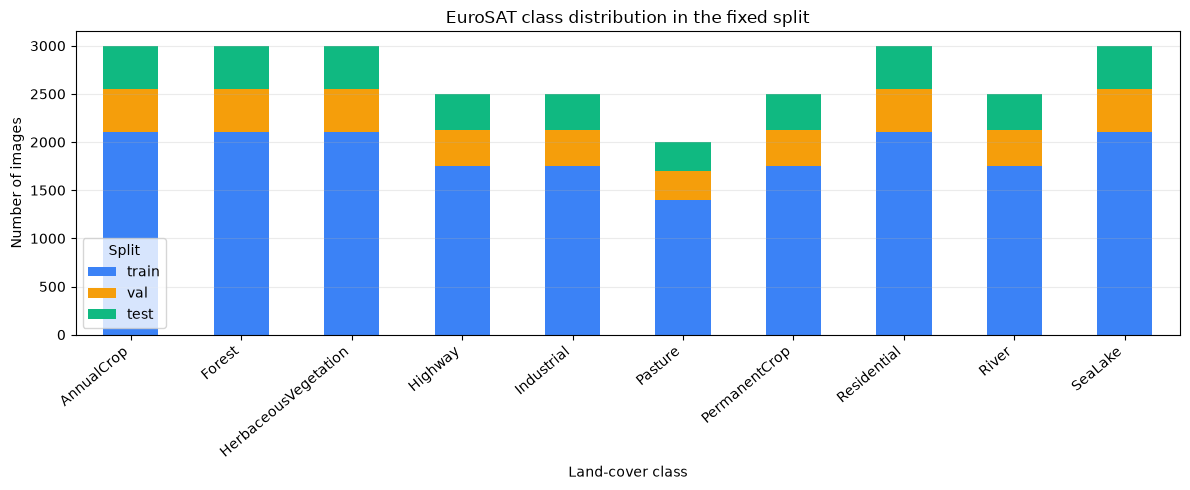

Largest/smallest class ratio: 1.50x


In [4]:
ax = class_by_split[["train", "val", "test"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    color=["#3b82f6", "#f59e0b", "#10b981"],
)
ax.set_title("EuroSAT class distribution in the fixed split")
ax.set_xlabel("Land-cover class")
ax.set_ylabel("Number of images")
ax.legend(title="Split")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

imbalance_ratio = class_by_split["total"].max() / class_by_split["total"].min()
print(f"Largest/smallest class ratio: {imbalance_ratio:.2f}x")

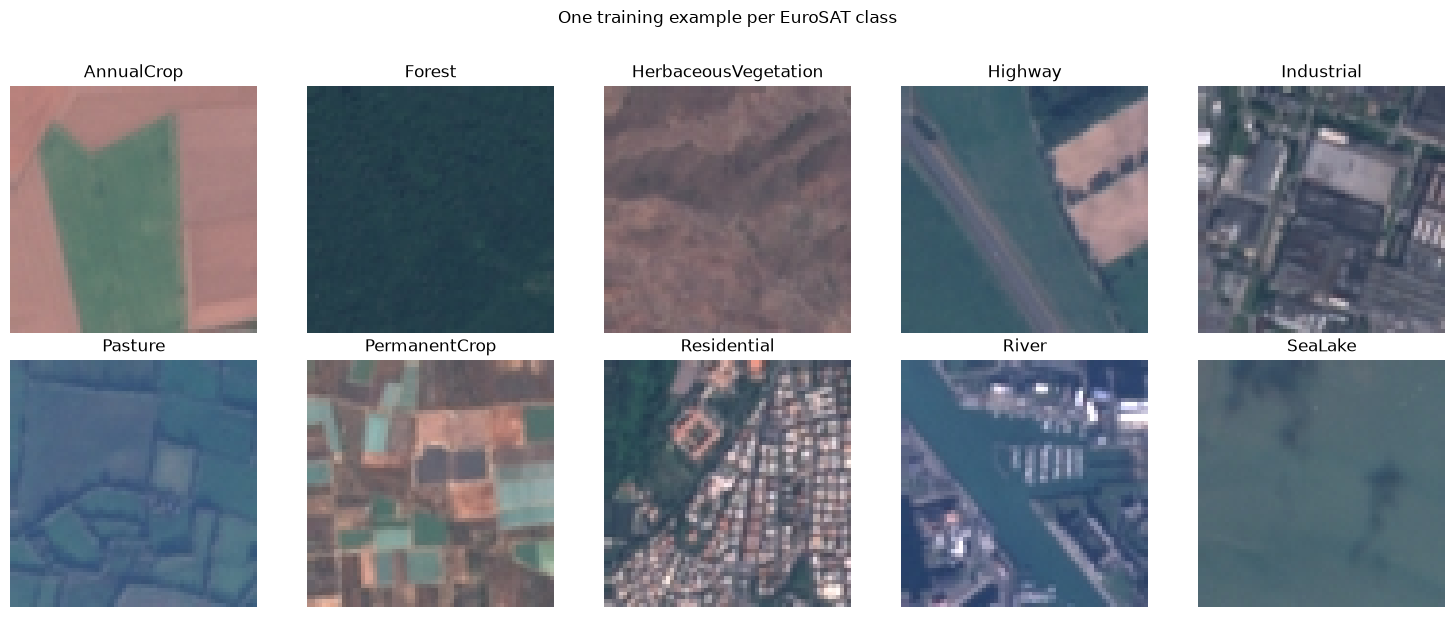

In [5]:
if DATA_AVAILABLE:
    sample_rows = (
        split_df[split_df["split"] == "train"]
        .groupby("label", group_keys=False)
        .sample(n=1, random_state=SEED)
        .sort_values("class_id")
    )
    figure, axes = plt.subplots(2, 5, figsize=(15, 6))
    for axis, row in zip(axes.flat, sample_rows.itertuples(index=False)):
        with Image.open(DATA_ROOT / row.filepath) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(row.label)
        axis.axis("off")
    figure.suptitle("One training example per EuroSAT class", y=1.02)
    figure.tight_layout()
    plt.show()
else:
    print("Sample-image preview skipped in portable review mode.")
    print("Set AUTO_DOWNLOAD_DATA=True and run all cells to display source images.")

### Data properties and challenges

- Images are small (64 x 64) RGB patches, while the ImageNet-pretrained model expects 224 x 224 input; upsampling may not recover fine spatial detail.
- Some categories have similar colour and texture patterns, especially PermanentCrop, AnnualCrop, and Pasture.
- Orientation is not semantically fixed in overhead imagery, so rotations and horizontal/vertical flips are appropriate augmentations.
- Class counts are moderately imbalanced (2,000-3,000 examples per class), motivating macro-F1 and per-class recall.
- A random image split may place geographically nearby patches in different splits. A geographic hold-out would be a stronger generalisation test.

### Preprocessing

Training uses random resized crops, flips, rotations, and mild colour jitter. Validation and test use deterministic resizing. All tensors use ImageNet normalisation for compatibility with pretrained weights. Augmentation is applied only to training images.

In [6]:
def get_pretrained_transforms(image_size: int = 224):
    train_transform = transforms.Compose(
        [
            transforms.RandomResizedCrop(image_size, scale=(0.90, 1.0), ratio=(0.90, 1.10)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=90),
            transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.15, hue=0.03),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )
    evaluation_transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )
    return train_transform, evaluation_transform


class EuroSATSplitDataset(Dataset):
    def __init__(self, data_root: Path, split_table: pd.DataFrame, split: str, transform=None):
        if split not in {"train", "val", "test"}:
            raise ValueError("Split must be train, val, or test.")
        self.data_root = Path(data_root)
        self.samples = split_table[split_table["split"] == split].copy().reset_index(drop=True)
        self.transform = transform
        self.classes = list(CLASSES)
        self.class_to_idx = dict(CLASS_TO_IDX)
        self.idx_to_class = {index: name for name, index in CLASS_TO_IDX.items()}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        row = self.samples.iloc[index]
        image_path = self.data_root / str(row["filepath"])
        with Image.open(image_path) as opened_image:
            image = opened_image.convert("RGB").copy()
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row["class_id"])


@dataclass
class DataLoaderBundle:
    train_loader: DataLoader
    val_loader: DataLoader
    test_loader: DataLoader
    train_dataset: EuroSATSplitDataset
    val_dataset: EuroSATSplitDataset
    test_dataset: EuroSATSplitDataset
    classes: list[str]
    class_to_idx: dict[str, int]
    idx_to_class: dict[int, str]


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def create_dataloaders(data_root: Path, split_table: pd.DataFrame) -> DataLoaderBundle:
    set_global_seed(SEED)
    train_transform, evaluation_transform = get_pretrained_transforms(IMAGE_SIZE)
    train_dataset = EuroSATSplitDataset(data_root, split_table, "train", train_transform)
    val_dataset = EuroSATSplitDataset(data_root, split_table, "val", evaluation_transform)
    test_dataset = EuroSATSplitDataset(data_root, split_table, "test", evaluation_transform)

    generator = torch.Generator().manual_seed(SEED)
    common = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": torch.cuda.is_available(),
        "worker_init_fn": seed_worker,
        "persistent_workers": NUM_WORKERS > 0,
    }
    return DataLoaderBundle(
        train_loader=DataLoader(train_dataset, shuffle=True, generator=generator, **common),
        val_loader=DataLoader(val_dataset, shuffle=False, **common),
        test_loader=DataLoader(test_dataset, shuffle=False, **common),
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
        classes=list(CLASSES),
        class_to_idx=dict(CLASS_TO_IDX),
        idx_to_class={index: name for name, index in CLASS_TO_IDX.items()},
    )


data = create_dataloaders(DATA_ROOT, split_df) if DATA_AVAILABLE else None
if data is not None:
    images, labels = next(iter(data.train_loader))
    print(f"Train / validation / test: {len(data.train_dataset)} / {len(data.val_dataset)} / {len(data.test_dataset)}")
    print(f"Batch tensors: images={tuple(images.shape)}, labels={tuple(labels.shape)}")
else:
    images = labels = None
    print("DataLoaders skipped because source images are not present.")
    print("Training remains available after setting AUTO_DOWNLOAD_DATA=True.")

Train / validation / test: 18900 / 4050 / 4050
Batch tensors: images=(32, 3, 224, 224), labels=(32,)


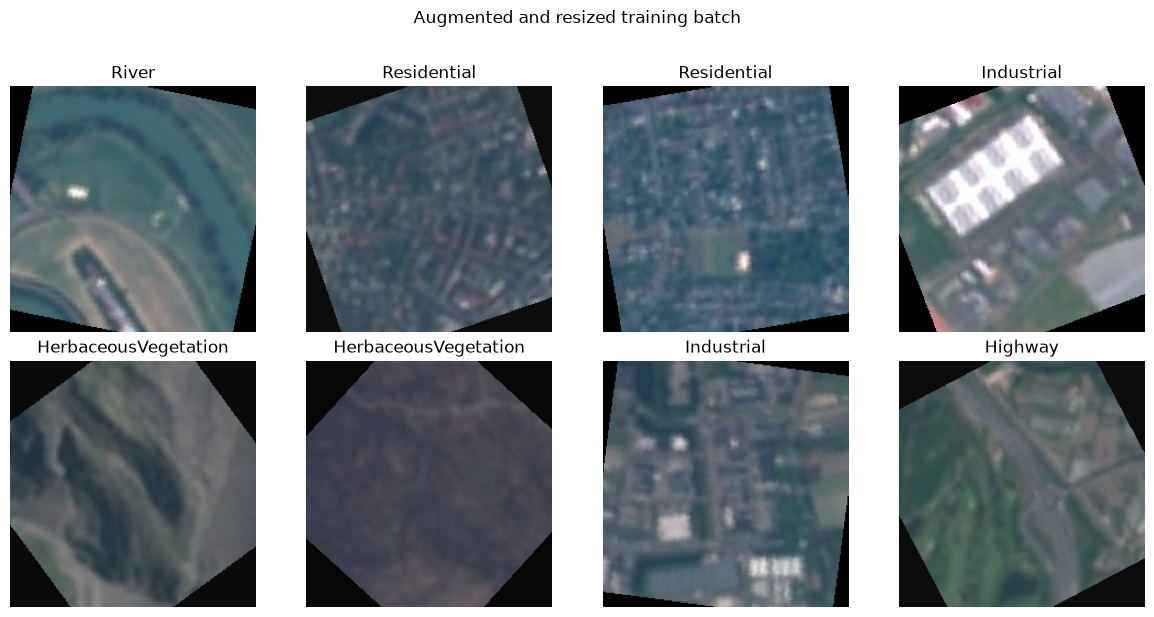

In [7]:
if data is not None:
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    preview = (images[:8].cpu() * std + mean).clamp(0, 1)

    figure, axes = plt.subplots(2, 4, figsize=(12, 6))
    for axis, image, label in zip(axes.flat, preview, labels[:8]):
        axis.imshow(image.permute(1, 2, 0))
        axis.set_title(CLASSES[int(label)])
        axis.axis("off")
    figure.suptitle("Augmented and resized training batch", y=1.02)
    figure.tight_layout()
    plt.show()
else:
    print("Augmented-batch preview skipped in review mode because images are not downloaded.")

# 4. Model and method

## 4.1 Why DeiT-Tiny?

DeiT-Tiny is a compact Vision Transformer. Each 224 x 224 image is divided into non-overlapping 16 x 16 patches, producing 196 patch tokens. Learned positional embeddings preserve spatial order, and 12 Transformer encoder blocks model long-range relationships using self-attention. The final classification head is replaced with a ten-class head.

The patch-embedding Conv2d is an efficient patch extraction and projection operation, not a CNN feature hierarchy.

## 4.2 Source attribution and our work

- Architecture and optional ImageNet weights: deit_tiny_patch16_224 from the open-source timm library, based on Touvron et al. (2021).
- Included project work: fixed split generation, dataset class, augmentation, DataLoaders, EuroSAT classification head, training/validation loop, macro-F1 checkpoint selection, early stopping, reproducibility controls, artifact saving, held-out evaluation, and error analysis.
- No distillation token or teacher model is used.

## 4.3 Optimisation

Fine-tuning uses AdamW, cosine annealing, cross-entropy with label smoothing, gradient clipping, and optional mixed precision. The best checkpoint is selected only by validation macro-F1.

In [8]:
MODEL_NAME = "deit_tiny_patch16_224"


def create_deit_tiny(num_classes: int, pretrained: bool = True, drop_rate: float = 0.0, drop_path_rate: float = 0.1):
    import timm
    return timm.create_model(
        MODEL_NAME,
        pretrained=pretrained,
        num_classes=num_classes,
        drop_rate=drop_rate,
        drop_path_rate=drop_path_rate,
    )


def model_summary(model: nn.Module) -> dict[str, Any]:
    return {
        "architecture": MODEL_NAME,
        "total_parameters": sum(parameter.numel() for parameter in model.parameters()),
        "trainable_parameters": sum(
            parameter.numel() for parameter in model.parameters() if parameter.requires_grad
        ),
    }


@dataclass
class EpochResult:
    loss: float
    accuracy: float
    macro_f1: float
    targets: np.ndarray
    predictions: np.ndarray


def aggregate_metrics(loss_sum, sample_count, targets, predictions) -> EpochResult:
    target_array = np.asarray(targets, dtype=np.int64)
    prediction_array = np.asarray(predictions, dtype=np.int64)
    return EpochResult(
        loss=loss_sum / max(sample_count, 1),
        accuracy=float(accuracy_score(target_array, prediction_array)),
        macro_f1=float(f1_score(target_array, prediction_array, average="macro", zero_division=0)),
        targets=target_array,
        predictions=prediction_array,
    )


def train_one_epoch(model, loader, criterion, optimizer, device, scaler, amp_enabled, grad_clip):
    model.train()
    loss_sum = 0.0
    sample_count = 0
    targets_all, predictions_all = [], []
    for batch_images, batch_targets in loader:
        batch_images = batch_images.to(device, non_blocking=True)
        batch_targets = batch_targets.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=amp_enabled):
            logits = model(batch_images)
            loss = criterion(logits, batch_targets)
        scaler.scale(loss).backward()
        if grad_clip is not None:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        batch_size = batch_targets.size(0)
        loss_sum += float(loss.item()) * batch_size
        sample_count += batch_size
        targets_all.extend(batch_targets.detach().cpu().tolist())
        predictions_all.extend(logits.argmax(dim=1).detach().cpu().tolist())
    return aggregate_metrics(loss_sum, sample_count, targets_all, predictions_all)


@torch.inference_mode()
def evaluate(model, loader, criterion, device, amp_enabled):
    model.eval()
    loss_sum = 0.0
    sample_count = 0
    targets_all, predictions_all = [], []
    for batch_images, batch_targets in loader:
        batch_images = batch_images.to(device, non_blocking=True)
        batch_targets = batch_targets.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=amp_enabled):
            logits = model(batch_images)
            loss = criterion(logits, batch_targets)
        batch_size = batch_targets.size(0)
        loss_sum += float(loss.item()) * batch_size
        sample_count += batch_size
        targets_all.extend(batch_targets.cpu().tolist())
        predictions_all.extend(logits.argmax(dim=1).cpu().tolist())
    return aggregate_metrics(loss_sum, sample_count, targets_all, predictions_all)


def class_weights_from_ids(class_ids: Iterable[int], num_classes: int, device: torch.device):
    counts = np.bincount(np.fromiter(class_ids, dtype=np.int64), minlength=num_classes)
    weights = counts.sum() / (num_classes * counts.astype(np.float64))
    return torch.tensor(weights, dtype=torch.float32, device=device)


def save_json(data_object: Any, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data_object, indent=2, ensure_ascii=False), encoding="utf-8")


def save_history(history_rows: list[dict[str, float]], output_dir: Path) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(history_rows).to_csv(output_dir / "history.csv", index=False)


def save_evaluation_artifacts(result: EpochResult, classes: list[str], output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    labels = list(range(len(classes)))
    report = classification_report(
        result.targets,
        result.predictions,
        labels=labels,
        target_names=classes,
        output_dict=True,
        zero_division=0,
    )
    metrics = {
        "loss": result.loss,
        "accuracy": result.accuracy,
        "macro_f1": result.macro_f1,
        "classification_report": report,
    }
    save_json(metrics, output_dir / "test_metrics.json")
    matrix = confusion_matrix(result.targets, result.predictions, labels=labels)
    pd.DataFrame(matrix, columns=classes).to_csv(output_dir / "confusion_matrix.csv", index=False)
    return metrics, matrix


def make_checkpoint(model, optimizer, scheduler, epoch, best_score, config):
    return {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "epoch": epoch,
        "best_val_macro_f1": best_score,
        "classes": list(CLASSES),
        "class_to_idx": dict(CLASS_TO_IDX),
        "model_name": MODEL_NAME,
        "num_classes": len(CLASSES),
        "image_size": IMAGE_SIZE,
        "pretrained_initialization": PRETRAINED,
        "config": config,
    }


architecture_model = create_deit_tiny(
    num_classes=len(CLASSES),
    pretrained=False,
    drop_rate=DROP_RATE,
    drop_path_rate=DROP_PATH_RATE,
)
architecture = model_summary(architecture_model)
display(pd.Series(architecture, name="DeiT-Tiny configuration").to_frame())
print(architecture_model.get_classifier())
del architecture_model

,DeiT-Tiny configuration
architecture,deit_tiny_patch16_224
total_parameters,5526346
trainable_parameters,5526346


Linear(in_features=192, out_features=10, bias=True)


## 4.4 Experimental setup

| Item | Recorded experiment |
|---|---|
| Split | 18,900 train / 4,050 validation / 4,050 test |
| Random seed | 42 |
| Input | 224 x 224 RGB |
| Initialisation | ImageNet pretrained |
| Optimiser | AdamW, learning rate 5e-5, weight decay 0.05 |
| Scheduler | Cosine annealing |
| Loss | Cross-entropy, label smoothing 0.1 |
| Maximum epochs | 50 |
| Early stopping | 8 epochs without validation macro-F1 improvement |
| Recorded DataLoader workers | 4 |
| Primary selection metric | Validation macro-F1 |
| Final metrics | Test loss, accuracy, macro-F1, per-class metrics, confusion matrix |

The portable default uses zero DataLoader workers for compatibility with Windows notebooks. This affects loading throughput, not the model definition or evaluation protocol.

In [9]:
history = []
best_checkpoint = OUTPUT_DIR / "best_model.pt"

if RUN_TRAINING:
    if data is None:
        raise RuntimeError(
            "Training requires images. Set AUTO_DOWNLOAD_DATA=True, restart the kernel, and run all cells."
        )
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    set_global_seed(SEED, deterministic=DETERMINISTIC)
    model = create_deit_tiny(
        num_classes=len(CLASSES),
        pretrained=PRETRAINED,
        drop_rate=DROP_RATE,
        drop_path_rate=DROP_PATH_RATE,
    ).to(DEVICE)

    weights = None
    if USE_CLASS_WEIGHTS:
        weights = class_weights_from_ids(
            data.train_dataset.samples["class_id"].astype(int).tolist(),
            len(CLASSES),
            DEVICE,
        )
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)
    config = {
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "image_size": IMAGE_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "label_smoothing": LABEL_SMOOTHING,
        "drop_rate": DROP_RATE,
        "drop_path_rate": DROP_PATH_RATE,
        "grad_clip": GRAD_CLIP,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "seed": SEED,
        "pretrained": PRETRAINED,
        "amp": USE_AMP,
        "class_weights": USE_CLASS_WEIGHTS,
    }
    save_json(
        {
            **model_summary(model),
            "started_at": datetime.now().astimezone().isoformat(),
            "device": str(DEVICE),
            "cuda_device": torch.cuda.get_device_name(DEVICE) if DEVICE.type == "cuda" else None,
            "python": sys.version,
            "platform": platform.platform(),
            "torch": torch.__version__,
            "train_samples": len(data.train_dataset),
            "validation_samples": len(data.val_dataset),
            "test_samples_not_used_for_training": len(data.test_dataset),
            "classes": CLASSES,
            "config": config,
        },
        OUTPUT_DIR / "run_config.json",
    )

    best_score = -1.0
    epochs_without_improvement = 0
    training_start = time.perf_counter()
    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.perf_counter()
        train_result = train_one_epoch(
            model, data.train_loader, criterion, optimizer, DEVICE,
            scaler, AMP_ENABLED, GRAD_CLIP,
        )
        val_result = evaluate(model, data.val_loader, criterion, DEVICE, AMP_ENABLED)
        row = {
            "epoch": float(epoch),
            "learning_rate": float(optimizer.param_groups[0]["lr"]),
            "train_loss": train_result.loss,
            "train_accuracy": train_result.accuracy,
            "train_macro_f1": train_result.macro_f1,
            "val_loss": val_result.loss,
            "val_accuracy": val_result.accuracy,
            "val_macro_f1": val_result.macro_f1,
            "epoch_seconds": time.perf_counter() - epoch_start,
        }
        history.append(row)
        improved = val_result.macro_f1 > best_score
        if improved:
            best_score = val_result.macro_f1
            epochs_without_improvement = 0
            torch.save(make_checkpoint(model, optimizer, scheduler, epoch, best_score, config), best_checkpoint)
        else:
            epochs_without_improvement += 1
        print(
            f"Epoch {epoch:03d}/{EPOCHS:03d} | train loss {train_result.loss:.4f}, "
            f"acc {train_result.accuracy:.4f}, F1 {train_result.macro_f1:.4f} | "
            f"val loss {val_result.loss:.4f}, acc {val_result.accuracy:.4f}, "
            f"F1 {val_result.macro_f1:.4f}" + (" | saved best" if improved else "")
        )
        scheduler.step()
        save_history(history, OUTPUT_DIR)
        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping after {PATIENCE} epochs without improvement.")
            break

    save_json(
        {
            "best_validation_macro_f1": best_score,
            "best_checkpoint": str(best_checkpoint),
            "epochs_completed": len(history),
            "total_training_seconds": time.perf_counter() - training_start,
            "finished_at": datetime.now().astimezone().isoformat(),
        },
        OUTPUT_DIR / "training_summary.json",
    )
else:
    print("Training skipped in portable review mode.")
    print("Set AUTO_DOWNLOAD_DATA=True and RUN_TRAINING=True to train a new model.")

Training skipped in portable review mode.
Set AUTO_DOWNLOAD_DATA=True and RUN_TRAINING=True to train a new model.


# 5. Training and validation results

The recorded history is embedded in this notebook. If a new local training run exists, the notebook automatically prefers its history.csv; otherwise it reconstructs the verified reference run. Thus the numerical table and curves remain reproducible when this ipynb is the only submitted file.

Result source: local history.csv
BEST VALIDATION CHECKPOINT
Epoch:               5
Validation loss:     0.5522
Validation accuracy: 0.9798 (97.98%)
Validation macro-F1: 0.9796


,Metric,Value
0,Best epoch,5.0000
1,Validation loss,0.5522
2,Validation accuracy,0.9798
3,Validation macro-F1,0.9796


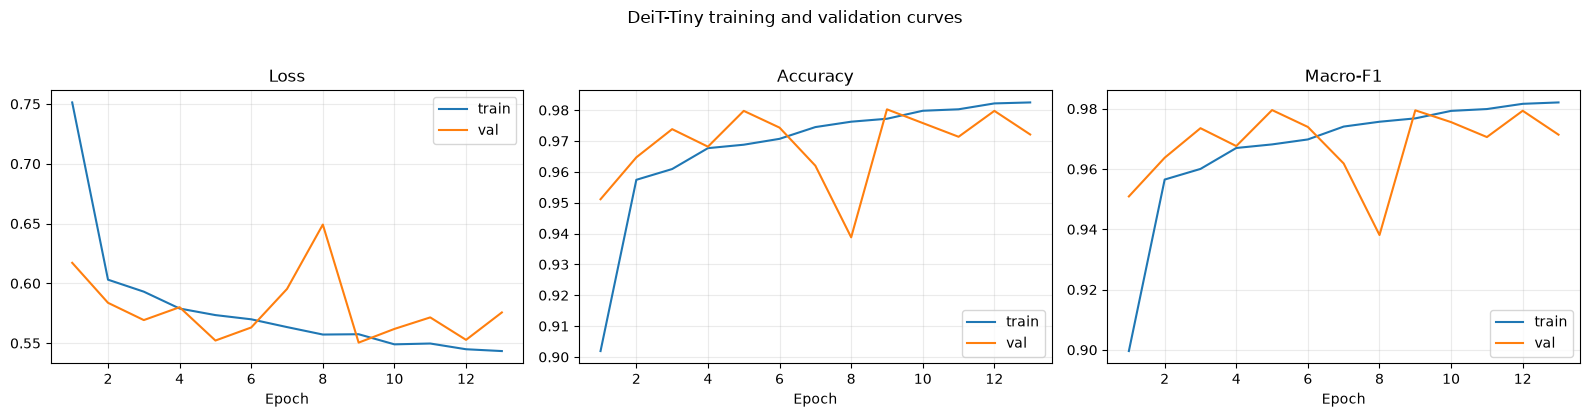

In [10]:
history_path = OUTPUT_DIR / "history.csv"
if history_path.is_file():
    history_df = pd.read_csv(history_path)
    history_source = "local history.csv"
elif USE_EMBEDDED_RESULTS:
    history_df = pd.DataFrame(EMBEDDED_HISTORY)
    history_source = "results embedded in this notebook"
else:
    history_df = None
    history_source = "unavailable"

if history_df is not None:
    best_row = history_df.loc[history_df["val_macro_f1"].idxmax()]
    print(f"Result source: {history_source}")
    print("=" * 64)
    print("BEST VALIDATION CHECKPOINT")
    print("=" * 64)
    print(f"Epoch:               {int(best_row['epoch'])}")
    print(f"Validation loss:     {best_row['val_loss']:.4f}")
    print(f"Validation accuracy: {best_row['val_accuracy']:.4f} ({best_row['val_accuracy'] * 100:.2f}%)")
    print(f"Validation macro-F1: {best_row['val_macro_f1']:.4f}")

    validation_summary = pd.DataFrame(
        {
            "Metric": ["Best epoch", "Validation loss", "Validation accuracy", "Validation macro-F1"],
            "Value": [int(best_row["epoch"]), best_row["val_loss"], best_row["val_accuracy"], best_row["val_macro_f1"]],
        }
    )
    display(validation_summary.style.format({"Value": "{:.4f}"}))

    figure, axes = plt.subplots(1, 3, figsize=(16, 4))
    for split_name in ["train", "val"]:
        axes[0].plot(history_df["epoch"], history_df[f"{split_name}_loss"], label=split_name)
        axes[1].plot(history_df["epoch"], history_df[f"{split_name}_accuracy"], label=split_name)
        axes[2].plot(history_df["epoch"], history_df[f"{split_name}_macro_f1"], label=split_name)
    for axis, title in zip(axes, ["Loss", "Accuracy", "Macro-F1"]):
        axis.set_title(title)
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.25)
        axis.legend()
    figure.suptitle("DeiT-Tiny training and validation curves", y=1.03)
    figure.tight_layout()
    plt.show()
else:
    print("No training history is available.")

# 6. Held-out test results and error analysis

**Test-set policy:** RUN_TEST should be enabled only after architecture and hyperparameters are final. In default review mode, this section uses the verified metrics embedded below; it does not access test images or recalculate predictions.

In [11]:
test_output_dir = OUTPUT_DIR / "test"
test_metrics_path = test_output_dir / "test_metrics.json"
local_matrix = None

if RUN_TEST:
    if data is None:
        raise RuntimeError(
            "Testing requires images. Set AUTO_DOWNLOAD_DATA=True, restart the kernel, and run all cells."
        )
    if not best_checkpoint.is_file():
        raise FileNotFoundError(f"Train the model first; missing {best_checkpoint}")
    checkpoint = torch.load(best_checkpoint, map_location=DEVICE, weights_only=True)
    if list(checkpoint["classes"]) != CLASSES:
        raise ValueError("Checkpoint and dataset class orders do not match.")
    test_model = create_deit_tiny(num_classes=len(CLASSES), pretrained=False).to(DEVICE)
    test_model.load_state_dict(checkpoint["model_state_dict"], strict=True)
    test_result = evaluate(
        test_model,
        data.test_loader,
        nn.CrossEntropyLoss(),
        DEVICE,
        AMP_ENABLED,
    )
    test_metrics, local_matrix = save_evaluation_artifacts(
        test_result, CLASSES, test_output_dir
    )
    test_result_source = f"new evaluation of checkpoint epoch {checkpoint.get('epoch', 'unknown')}"
elif test_metrics_path.is_file():
    test_metrics = json.loads(test_metrics_path.read_text(encoding="utf-8"))
    test_result_source = "local test_metrics.json"
elif USE_EMBEDDED_RESULTS:
    test_metrics = EMBEDDED_TEST_METRICS
    test_result_source = "verified results embedded in this notebook"
else:
    test_metrics = None
    test_result_source = "unavailable"

print(f"Test result source: {test_result_source}")

Test result source: local test_metrics.json


FINAL HELD-OUT TEST RESULTS
Test loss:           0.1458
Test accuracy:       0.9802 (98.02%)
Test macro-F1:       0.9796
Correct predictions: 3,970 / 4,050


,Metric,Value
0,Test loss,0.1458
1,Test accuracy,0.9802
2,Test macro-F1,0.9796
3,Correct predictions,3970.0000
4,Test samples,4050.0000



Per-class precision, recall, F1 and support:


,precision,recall,f1-score,support
Class,,,,
AnnualCrop,0.9685,0.9556,0.9620,450
Forest,0.9933,0.9911,0.9922,450
HerbaceousVegetation,0.9799,0.9733,0.9766,450
Highway,0.9865,0.9733,0.9799,375
Industrial,0.9946,0.9867,0.9906,375
Pasture,0.9729,0.9567,0.9647,300
PermanentCrop,0.9291,0.9787,0.9532,375
Residential,0.9890,0.9978,0.9934,450
River,0.9867,0.9893,0.9880,375


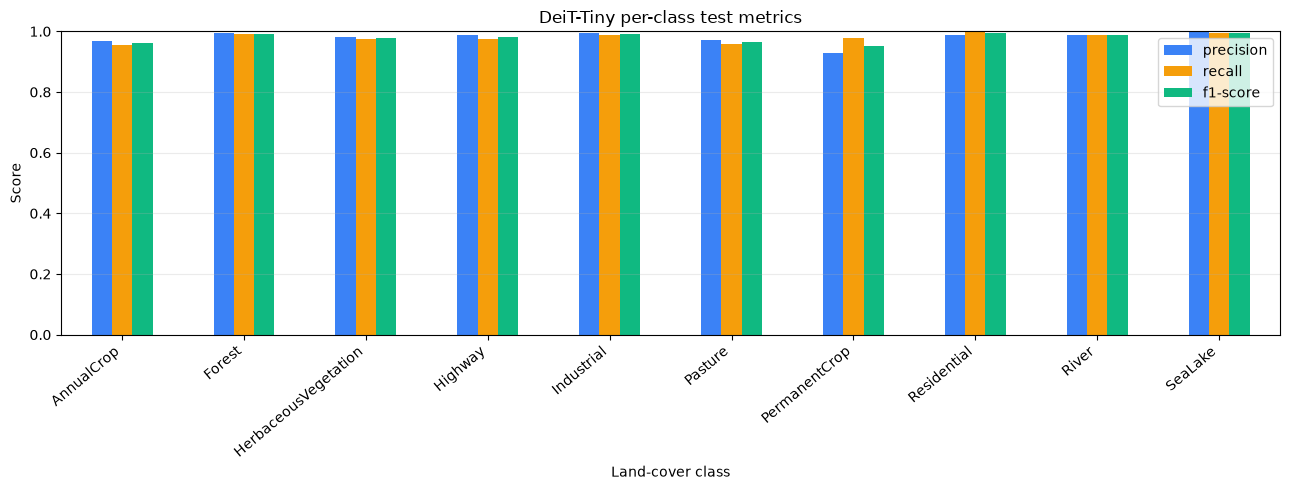

Lowest-recall class:  AnnualCrop (0.9556)
Highest-recall class: Residential (0.9978)


In [12]:
if test_metrics is not None:
    test_sample_count = int(test_metrics["classification_report"]["macro avg"]["support"])
    correct_count = int(round(test_metrics["accuracy"] * test_sample_count))
    test_summary = pd.DataFrame(
        {
            "Metric": ["Test loss", "Test accuracy", "Test macro-F1", "Correct predictions", "Test samples"],
            "Value": [
                test_metrics["loss"],
                test_metrics["accuracy"],
                test_metrics["macro_f1"],
                correct_count,
                test_sample_count,
            ],
        }
    )

    print("=" * 64)
    print("FINAL HELD-OUT TEST RESULTS")
    print("=" * 64)
    print(f"Test loss:           {test_metrics['loss']:.4f}")
    print(f"Test accuracy:       {test_metrics['accuracy']:.4f} ({test_metrics['accuracy'] * 100:.2f}%)")
    print(f"Test macro-F1:       {test_metrics['macro_f1']:.4f}")
    print(f"Correct predictions: {correct_count:,} / {test_sample_count:,}")
    display(test_summary.style.format({"Value": "{:.4f}"}))

    per_class = pd.DataFrame(test_metrics["classification_report"]).T.loc[CLASSES]
    per_class.index.name = "Class"
    print()
    print("Per-class precision, recall, F1 and support:")
    display(per_class.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1-score": "{:.4f}",
        "support": "{:.0f}",
    }))

    per_class[["precision", "recall", "f1-score"]].plot(
        kind="bar",
        figsize=(13, 5),
        ylim=(0, 1),
        color=["#3b82f6", "#f59e0b", "#10b981"],
    )
    plt.title("DeiT-Tiny per-class test metrics")
    plt.ylabel("Score")
    plt.xlabel("Land-cover class")
    plt.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=40, ha="right")
    plt.tight_layout()
    plt.show()

    worst_class = per_class["recall"].idxmin()
    best_class = per_class["recall"].idxmax()
    print(f"Lowest-recall class:  {worst_class} ({per_class.loc[worst_class, 'recall']:.4f})")
    print(f"Highest-recall class: {best_class} ({per_class.loc[best_class, 'recall']:.4f})")
else:
    print("No test metrics are available.")

Confusion-matrix source: local confusion_matrix.csv
NUMERICAL CONFUSION MATRIX (counts)


Predicted label,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
True label,,,,,,,,,,
AnnualCrop,430,0,0,0,0,2,17,0,0,1
Forest,0,446,3,0,0,0,0,1,0,0
HerbaceousVegetation,0,3,438,0,0,3,6,0,0,0
Highway,1,0,0,365,1,2,3,1,2,0
Industrial,0,0,0,2,370,0,0,3,0,0
Pasture,9,0,2,0,0,287,1,0,1,0
PermanentCrop,3,0,4,0,0,1,367,0,0,0
Residential,0,0,0,0,1,0,0,449,0,0
River,0,0,0,3,0,0,1,0,371,0


Diagonal correct predictions: 3,970
Off-diagonal errors:           80


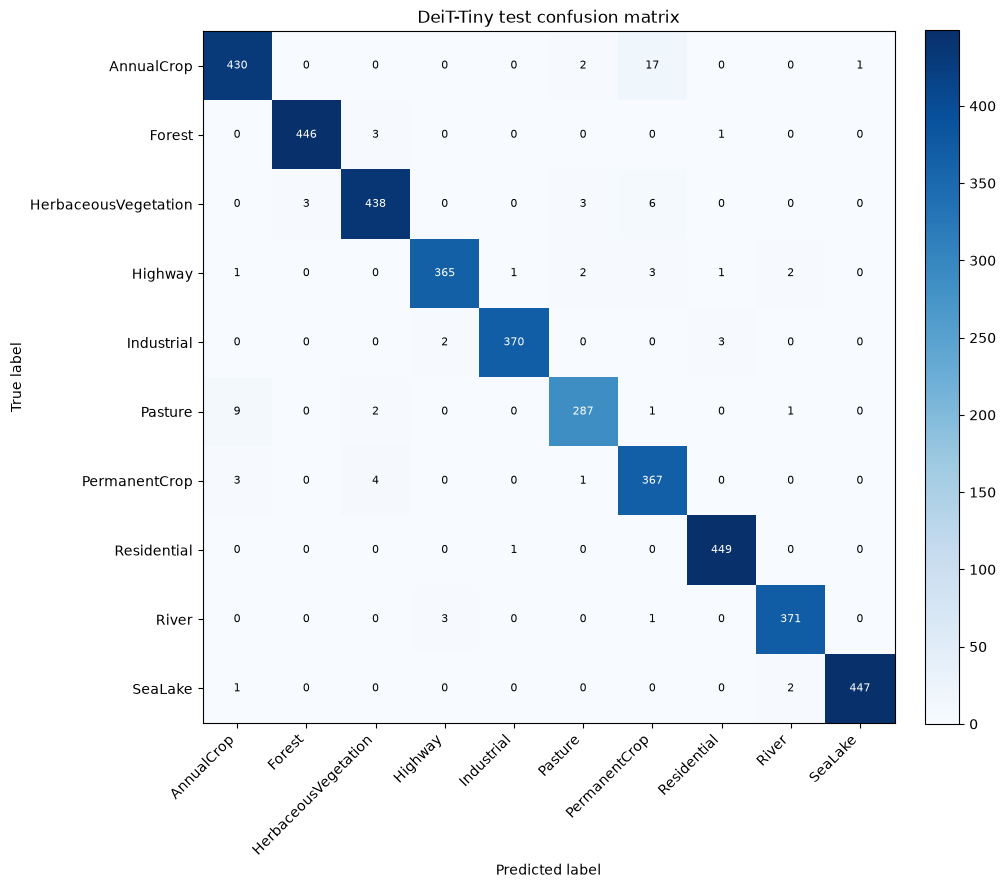

In [13]:
matrix_path = test_output_dir / "confusion_matrix.csv"
if local_matrix is not None:
    matrix = np.asarray(local_matrix, dtype=int)
    matrix_source = "new held-out evaluation"
elif matrix_path.is_file():
    matrix = pd.read_csv(matrix_path).to_numpy(dtype=int)
    matrix_source = "local confusion_matrix.csv"
elif USE_EMBEDDED_RESULTS:
    matrix = np.asarray(EMBEDDED_CONFUSION_MATRIX, dtype=int)
    matrix_source = "verified matrix embedded in this notebook"
else:
    matrix = None
    matrix_source = "unavailable"

if matrix is not None:
    matrix_df = pd.DataFrame(matrix, index=CLASSES, columns=CLASSES)
    matrix_df.index.name = "True label"
    matrix_df.columns.name = "Predicted label"
    print(f"Confusion-matrix source: {matrix_source}")
    print("NUMERICAL CONFUSION MATRIX (counts)")
    display(matrix_df)
    print(f"Diagonal correct predictions: {int(np.trace(matrix)):,}")
    print(f"Off-diagonal errors:           {int(matrix.sum() - np.trace(matrix)):,}")

    figure, axis = plt.subplots(figsize=(10, 9))
    image = axis.imshow(matrix, cmap="Blues")
    figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    axis.set(
        xticks=np.arange(len(CLASSES)),
        yticks=np.arange(len(CLASSES)),
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        xlabel="Predicted label",
        ylabel="True label",
        title="DeiT-Tiny test confusion matrix",
    )
    plt.setp(axis.get_xticklabels(), rotation=45, ha="right")
    threshold = matrix.max() / 2
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            axis.text(
                column_index,
                row_index,
                str(matrix[row_index, column_index]),
                ha="center",
                va="center",
                fontsize=8,
                color="white" if matrix[row_index, column_index] > threshold else "black",
            )
    figure.tight_layout()
    plt.show()
else:
    print("No confusion matrix is available.")

## Optional group-model comparison

This cell discovers standardised local result files when they exist. In a notebook-only submission, it still includes the embedded DeiT-Tiny result. Add other group models to this same notebook rather than submitting additional notebooks.

,accuracy,macro_f1
model,,
deit_tiny,0.9802,0.9796


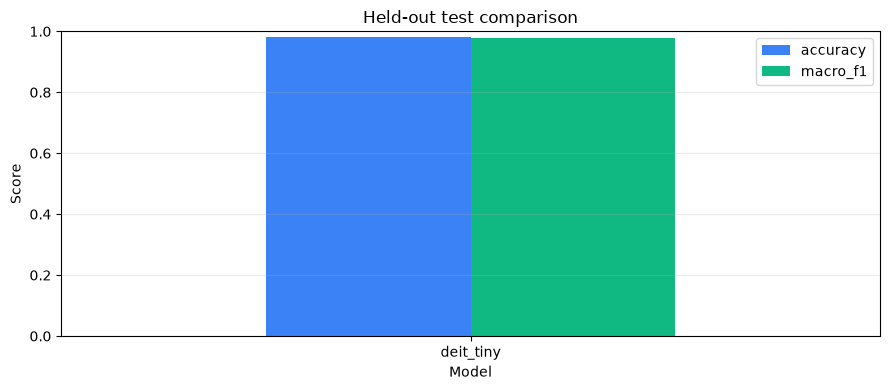

In [14]:
comparison_rows = []
for metric_path in sorted((PROJECT_ROOT / "outputs").glob("*/test/test_metrics.json")):
    metrics = json.loads(metric_path.read_text(encoding="utf-8"))
    comparison_rows.append(
        {
            "model": metric_path.parents[1].name,
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["macro_f1"],
        }
    )

if not comparison_rows and USE_EMBEDDED_RESULTS:
    comparison_rows.append(
        {
            "model": "DeiT-Tiny",
            "accuracy": EMBEDDED_TEST_METRICS["accuracy"],
            "macro_f1": EMBEDDED_TEST_METRICS["macro_f1"],
        }
    )

if comparison_rows:
    comparison_df = (
        pd.DataFrame(comparison_rows)
        .drop_duplicates(subset=["model"], keep="last")
        .set_index("model")
        .sort_values("macro_f1", ascending=False)
    )
    display(comparison_df.style.format("{:.4f}"))
    comparison_df.plot(
        kind="bar",
        figsize=(9, 4),
        ylim=(0, 1),
        color=["#3b82f6", "#10b981"],
    )
    plt.title("Held-out test comparison")
    plt.ylabel("Score")
    plt.xlabel("Model")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print("No model results are available.")

# 7. Discussion

## Main findings

The recorded run stopped after 13 epochs and selected epoch 5 by validation macro-F1 (0.9796). On the 4,050-image held-out test set, DeiT-Tiny achieved **98.02% accuracy** and **0.9796 macro-F1**. Residential had the highest recall (0.9978); AnnualCrop had the lowest recall (0.9556), followed closely by Pasture (0.9567).

The largest single confusion was **AnnualCrop predicted as PermanentCrop (17 images)**. Both classes contain repeated agricultural textures and seasonal colour variation. PermanentCrop also had the lowest precision (0.9291), consistent with several vegetation classes being attracted to that label.

## Strengths

- The split, class order, seed, preprocessing, checkpoint criterion, and metrics are fixed and documented.
- Macro-F1 and per-class recall reveal performance hidden by overall accuracy.
- ImageNet pretraining makes a Transformer practical on a medium-sized dataset, while DeiT-Tiny uses approximately 5.53 million parameters.
- Test data are excluded from model selection.
- The notebook now contains the full implementation and embedded evidence, so it remains readable and executable as one file.

## Weaknesses and limitations

- Resizing 64 x 64 inputs to 224 x 224 increases computation without adding information.
- A random image split measures in-distribution classification, not robustness to new countries, seasons, sensors, or acquisition conditions.
- A single seed does not quantify training variance.
- Review mode reproduces recorded tables and plots but does not claim to recalculate predictions. A fresh test calculation requires downloaded data and the checkpoint produced by training mode.
- Full training is hardware-dependent and can be slow on CPU.

## Future work

Evaluate geographic hold-outs, repeat experiments across seeds, compare ResNet50 and EfficientNet under the same protocol, investigate remote-sensing pretraining, and add calibration and explainability analysis.

## Conclusion

DeiT-Tiny provides strong in-distribution performance on the supplied EuroSAT protocol: the best validation checkpoint reached 0.9796 macro-F1, followed by 98.02% test accuracy and 0.9796 test macro-F1. Remaining errors concentrate in visually similar agricultural categories.

# 8. Reproducibility and portability

This notebook contains:

- dependency detection and optional installation;
- optional EuroSAT download through torchvision;
- deterministic stratified split construction;
- dataset, augmentation, and DataLoader code;
- DeiT-Tiny model construction;
- training, validation, checkpoint, and test code;
- embedded verified history, metrics, and confusion matrix;
- numerical tables and plotted evidence.

### Review mode versus recomputation

Review mode is designed for a notebook-only submission: it does not require data or external output files, and explicitly labels embedded result sources. Training mode downloads data when authorised and writes new artifacts under outputs/deit_tiny. Held-out testing then loads the new best_model.pt.

The embedded values are not fabricated demonstration data; they are a portable copy of the recorded experiment artifacts. Keeping them inside the notebook ensures that clearing external folders does not remove the evidence required by the marking rubric.

# References

1. Helber, P., Bischke, B., Dengel, A., & Borth, D. (2019). *EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification*. IEEE JSTARS. https://arxiv.org/abs/1709.00029
2. EuroSAT RGB dataset archive, Zenodo, DOI 10.5281/zenodo.7711810. https://zenodo.org/records/7711810
3. Touvron, H., et al. (2021). *Training data-efficient image transformers & distillation through attention*. ICML. https://proceedings.mlr.press/v139/touvron21a.html
4. Wightman, R., et al. *PyTorch Image Models (timm)*. https://github.com/huggingface/pytorch-image-models
5. Dosovitskiy, A., et al. (2021). *An Image is Worth 16x16 Words*. ICLR. https://arxiv.org/abs/2010.11929

---
## Final submission checklist

- [ ] Fill in all group member names and zIDs.
- [x] Exactly one ipynb contains the current implementation.
- [x] Project-specific source code is embedded; no src folder is required.
- [x] Review mode runs without the dataset or outputs directory.
- [x] Numerical results, tables, and figures are embedded.
- [x] Training and held-out test modes remain available.
- [ ] Merge other group models into this notebook if applicable.
- [ ] Confirm the course submission policy for pretrained checkpoints and raw data.
- [ ] Open the final saved file once before upload and verify all outputs render.